In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

master = pd.read_csv(
    "../data/processed/listing_master.csv"
)

master.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,listing_id,total_reviews,first_review_y,last_review_y,median_price,listing_density,average_rating,host_tenure_years,review_frequency,price_per_bedroom
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,13913.0,55.0,2010-08-18,2025-08-21,141.0,5036,4.724966,16.610959,3.311067,70.0
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,15400.0,97.0,2009-12-21,2025-04-05,225.0,6401,4.714067,16.558904,5.857876,149.0
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,17402.0,56.0,2011-03-21,2024-02-19,220.0,11385,4.665023,16.476712,3.398736,137.0
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,24328.0,95.0,2010-11-15,2025-07-05,140.0,4965,4.787750,16.745205,5.673266,NaN
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,36274.0,15.0,2011-03-20,2025-09-06,127.0,7469,4.680864,16.084932,0.932550,210.0


In [2]:
#Descriptive Statistics
master.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_id,total_reviews,median_price,listing_density,average_rating,host_tenure_years,review_frequency,price_per_bedroom
count,9.687100e+04,9.687100e+04,9.687100e+04,96830.000000,96830.000000,96871.000000,96871.000000,96871.000000,62025.00000,84096.000000,...,96871.000000,72749.000000,7.274900e+04,72749.000000,96871.000000,96871.000000,96871.000000,96830.000000,96830.000000,5.945500e+04
mean,6.894448e+17,2.025091e+13,2.144494e+08,50.088991,80.305246,51.509740,-0.127638,3.326228,1.35555,1.607092,...,0.028553,0.990334,6.500916e+17,28.838829,138.228283,5150.892310,4.720896,8.417402,2.914458,1.584890e+02
std,5.941222e+17,0.000000e+00,2.196053e+08,399.405694,589.326173,0.049067,0.101112,2.078605,0.72077,1.040425,...,0.631484,1.304282,5.781296e+17,56.312753,45.938422,3038.366638,0.042818,3.896184,6.377011,4.509531e+03
min,1.391300e+04,2.025091e+13,2.594000e+03,1.000000,1.000000,51.295937,-0.496760,1.000000,0.00000,0.000000,...,0.000000,0.010000,1.391300e+04,1.000000,70.000000,477.000000,4.659560,0.778082,0.000000,3.428571e+00
25%,3.026058e+07,2.025091e+13,2.726814e+07,1.000000,1.000000,51.484150,-0.189468,2.000000,1.00000,1.000000,...,0.000000,0.150000,2.961989e+07,3.000000,107.000000,2529.000000,4.680864,4.832877,0.067297,6.200000e+01
50%,8.505248e+17,2.025091e+13,1.164321e+08,2.000000,3.000000,51.513720,-0.127505,2.000000,1.00000,1.000000,...,0.000000,0.520000,7.805094e+17,10.000000,126.000000,5190.000000,4.722280,9.347945,0.646171,9.366667e+01
75%,1.254262e+18,2.025091e+13,4.198974e+08,10.000000,14.000000,51.539108,-0.068316,4.000000,1.50000,2.000000,...,0.000000,1.290000,1.197302e+18,30.000000,160.000000,6551.000000,4.759615,11.358904,2.876888,1.440000e+02
max,1.508964e+18,2.025091e+13,7.186905e+08,5469.000000,8769.000000,51.682630,0.278960,16.000000,26.00000,50.000000,...,25.000000,36.960000,1.508900e+18,1902.000000,248.000000,11385.000000,4.817984,17.830137,347.115000,1.085147e+06


In [3]:
master.describe().to_csv(
    "../reports/summary_statistics.csv"
)

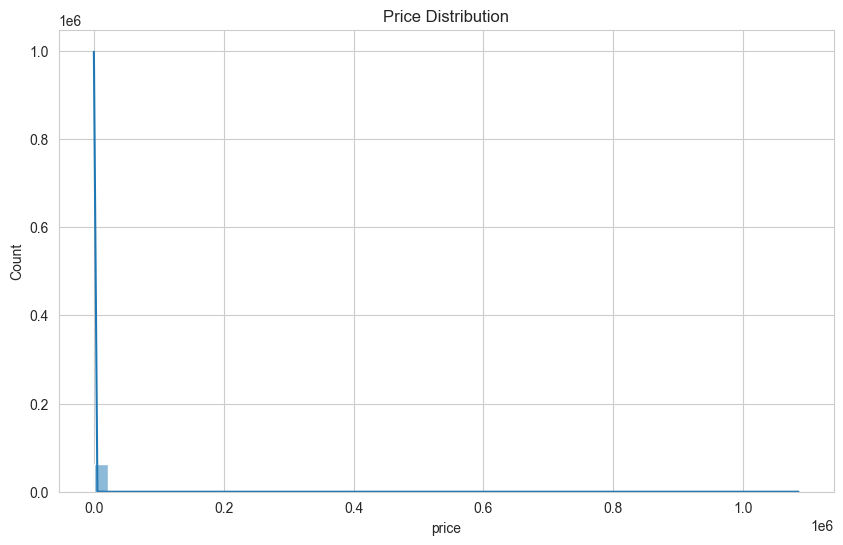

In [10]:
# Price Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    master["price"],
    bins=50,
    kde=True
)

plt.title("Price Distribution")
plt.show()



In [5]:
plt.savefig(
    "../reports/price_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

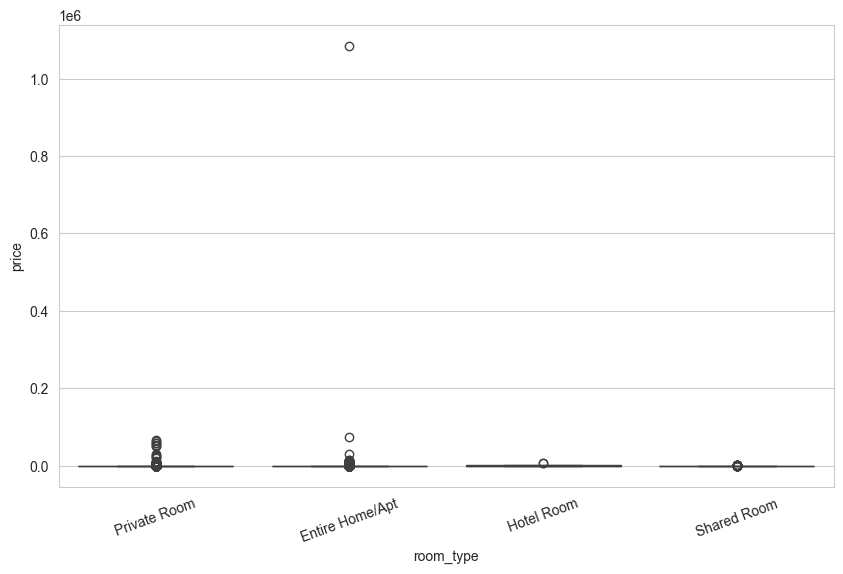

In [11]:
#Price by Room Type
plt.figure(figsize=(10,6))

sns.boxplot(
    data=master,
    x="room_type",
    y="price"
)

plt.xticks(rotation=20)

plt.show()



In [7]:
plt.savefig(
    "../reports/Price by Room Type.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

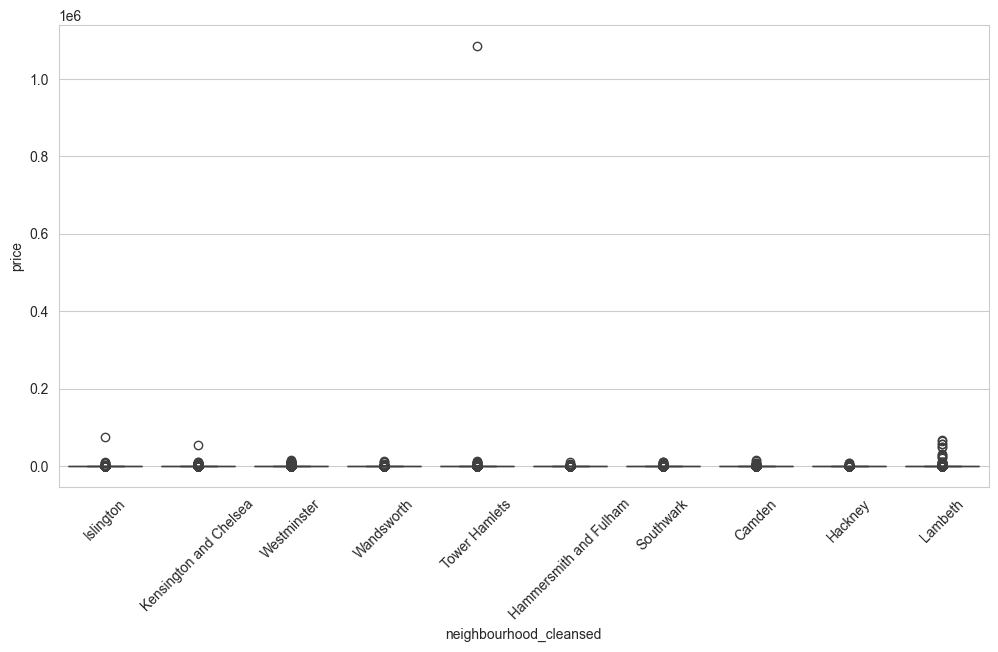

In [12]:
#Price by Neighbourhood

top_neighbourhoods = (
    master["neighbourhood_cleansed"]
    .value_counts()
    .head(10)
    .index
)

subset = master[
    master["neighbourhood_cleansed"]
    .isin(top_neighbourhoods)
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=subset,
    x="neighbourhood_cleansed",
    y="price"
)

plt.xticks(rotation=45)

plt.show()

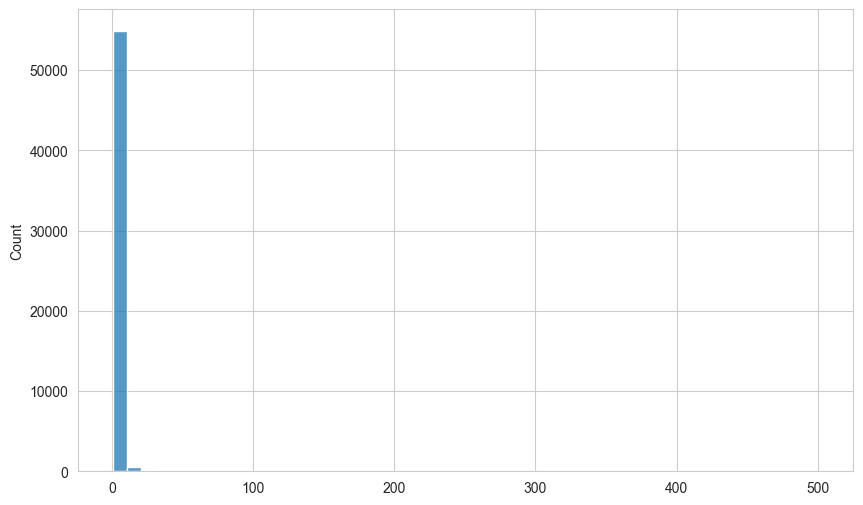

In [13]:
#Listings Per Host
host_counts = (
    master.groupby("host_id")
    .size()
)

plt.figure(figsize=(10,6))

sns.histplot(
    host_counts,
    bins=50
)

plt.show()

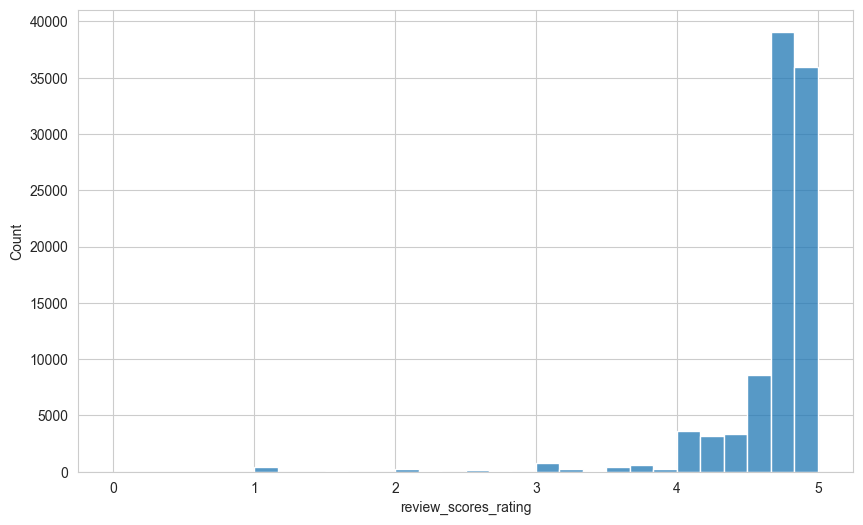

In [14]:
#Review Score Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    master["review_scores_rating"],
    bins=30
)

plt.show()

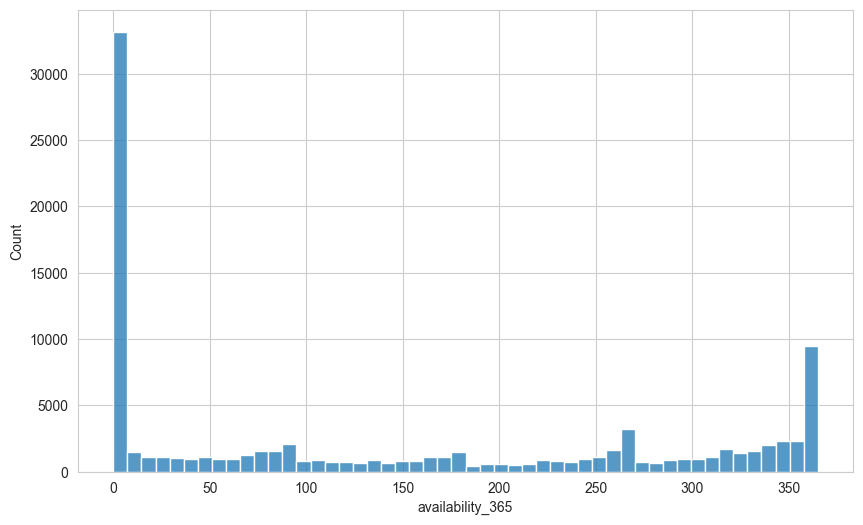

In [15]:
#Availability Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    master["availability_365"],
    bins=50
)

plt.show()

4.2 Geographic & Spatial Analysis

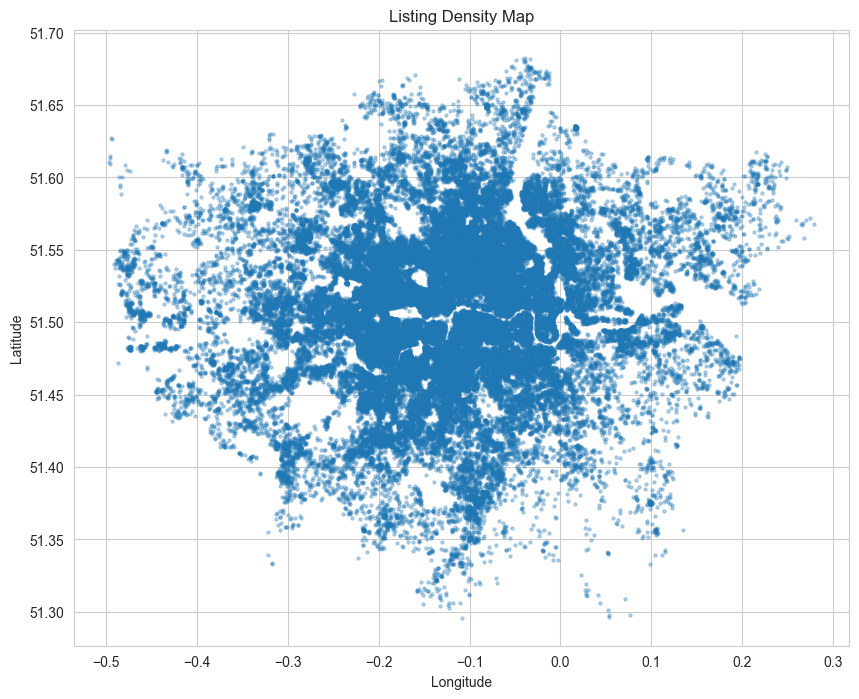

In [16]:
#Listing Density Map
plt.figure(figsize=(10,8))

plt.scatter(
    master["longitude"],
    master["latitude"],
    alpha=0.3,
    s=5
)

plt.title("Listing Density Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [17]:
plt.savefig(
    "../reports/listing_density_map.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

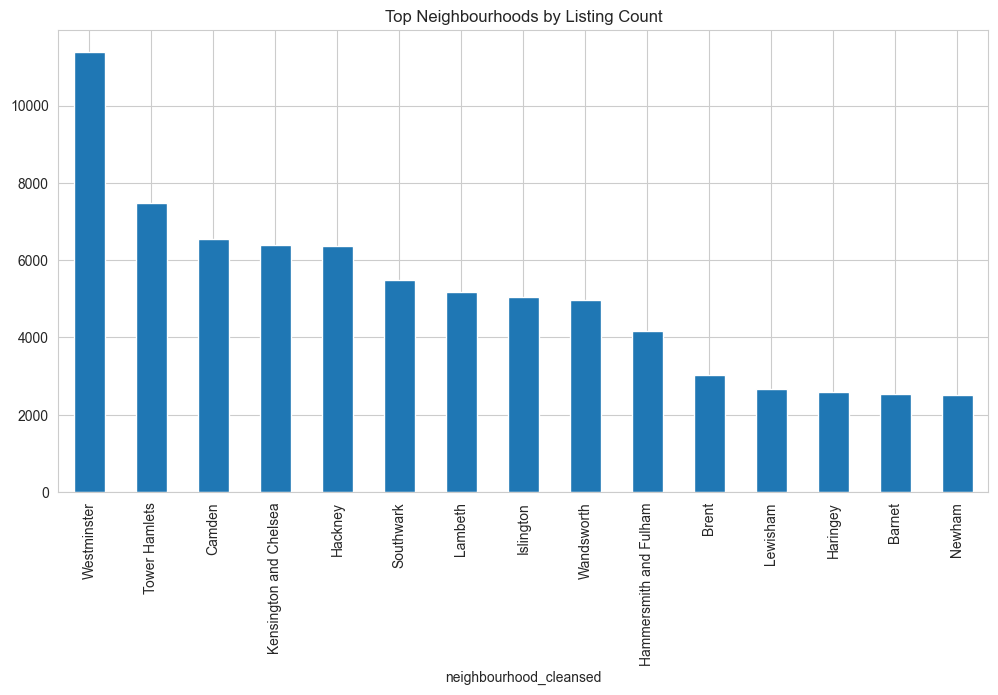

In [18]:
#Neighbourhood Listing Density
density = (
    master.groupby(
        "neighbourhood_cleansed"
    )
    .size()
    .sort_values(
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12,6))

density.plot(
    kind="bar"
)

plt.title(
    "Top Neighbourhoods by Listing Count"
)

plt.show()

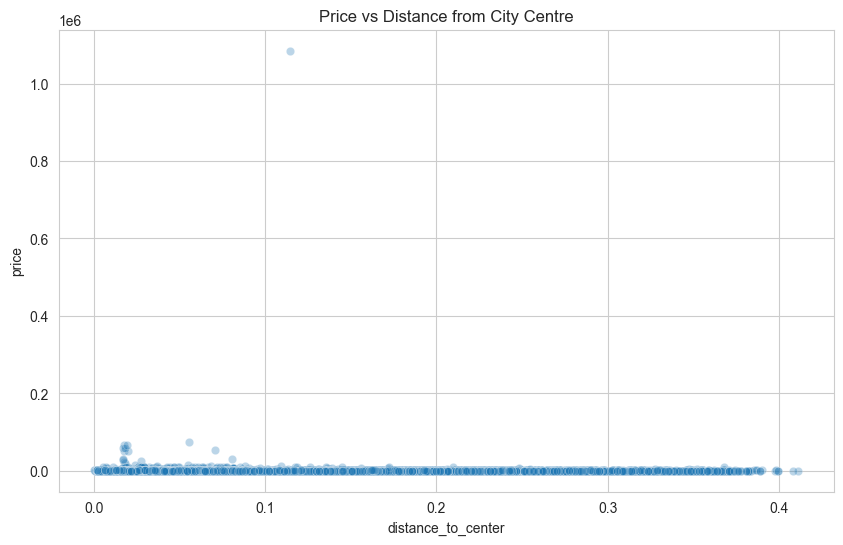

In [19]:
#Geographic Pricing Gradient
city_lat = 51.5074
city_lon = -0.1278

master["distance_to_center"] = (
    (
        master["latitude"] - city_lat
    ) ** 2
    +
    (
        master["longitude"] - city_lon
    ) ** 2
) ** 0.5

#Price vs Distance
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master,
    x="distance_to_center",
    y="price",
    alpha=0.3
)

plt.title(
    "Price vs Distance from City Centre"
)

plt.show()